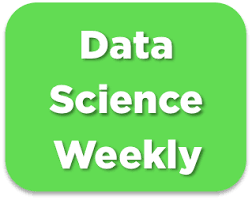

# Challenge : predict conversions 🏆🏆

This is the template that shows the different steps of the challenge. In this notebook, all the training/predictions steps are implemented for a very basic model (logistic regression with only one variable). Please use this template and feel free to change the preprocessing/training steps to get the model with the best f1-score ! May the force be with you 🧨🧨  

**For a detailed description of this project, please refer to *02-Conversion_rate_challenge.ipynb*.**

# Import libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score
from sklearn.pipeline import Pipeline

from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "notebook" # to be replaced by "iframe" if working on JULIE
from IPython.display import display

# Read file with labels

In [3]:
data = pd.read_csv('conversion_data_train.csv')
print('Set with labels (our train+test) :', data.shape)

Set with labels (our train+test) : (284580, 6)


In [4]:
data.head()

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


In [5]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              284580 non-null  object
 1   age                  284580 non-null  int64 
 2   new_user             284580 non-null  int64 
 3   source               284580 non-null  object
 4   total_pages_visited  284580 non-null  int64 
 5   converted            284580 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 13.0+ MB


In [6]:
data.describe(include='all')

,country,age,new_user,source,total_pages_visited,converted
count,284580,284580.000000,284580.000000,284580,284580.000000,284580.000000
unique,4,NaN,NaN,3,NaN,NaN
top,US,NaN,NaN,Seo,NaN,NaN
freq,160124,NaN,NaN,139477,NaN,NaN
mean,NaN,30.564203,0.685452,NaN,4.873252,0.032258
std,NaN,8.266789,0.464336,NaN,3.341995,0.176685
min,NaN,17.000000,0.000000,NaN,1.000000,0.000000
25%,NaN,24.000000,0.000000,NaN,2.000000,0.000000
50%,NaN,30.000000,1.000000,NaN,4.000000,0.000000
75%,NaN,36.000000,1.000000,NaN,7.000000,0.000000


# Explore dataset

In [7]:
# The dataset is quite big : you must create a sample of the dataset before making any visualizations !
data_sample = data.sample(10000)

# Make your model

## Choose variables to use in the model, and create train and test sets
**From the EDA, we know that the most useful feature is total_pages_visited. Let's create a baseline model by using at first only this feature : in the next cells, we'll make preprocessings and train a simple (univariate) logistic regression.**

In [8]:
target_variable = 'converted'
features_list = data.drop(columns=[target_variable]).columns

In [9]:
features_list

Index(['country', 'age', 'new_user', 'source', 'total_pages_visited'], dtype='object')

In [10]:
X = data.loc[:, features_list]
Y = data.loc[:, target_variable]

print('Explanatory variables : ', X.columns)
print()

Explanatory variables :  Index(['country', 'age', 'new_user', 'source', 'total_pages_visited'], dtype='object')



In [11]:
# Divide dataset Train set & Test set 
print("Dividing into train and test sets...")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=0)
print("...Done.")
print()

Dividing into train and test sets...
...Done.



In [12]:
numeric_features = X_train.select_dtypes(exclude=['object']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns
print(numeric_features)
print(categorical_features)

Index(['age', 'new_user', 'total_pages_visited'], dtype='object')
Index(['country', 'source'], dtype='object')


## Training pipeline

In [13]:
# Put here all the preprocessings
print("Encoding categorical features and standardizing numerical features...")

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_train = preprocessor.fit_transform(X_train)

print("...Done")
print(X_train[0:5,:])

Encoding categorical features and standardizing numerical features...


...Done
[[-0.91680706  0.6772713  -0.8592868   1.          0.          0.
   0.          0.        ]
 [-0.67467104  0.6772713  -1.15829275  0.          0.          0.
   0.          0.        ]
 [ 3.32057331  0.6772713  -1.15829275  0.          0.          0.
   0.          0.        ]
 [ 0.29387305  0.6772713  -0.2612749   0.          1.          0.
   0.          1.        ]
 [-0.79573905  0.6772713  -0.2612749   0.          0.          0.
   0.          1.        ]]


In [14]:
# Train model (LightGBM)
print("Train model...")

classifier = LGBMClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=5, random_state=0, verbosity=-1
)
classifier.fit(X_train, Y_train)

print("...Done.")

Train model...
...Done.


In [15]:
# Predictions on training set
print("Predictions on training set...")
Y_train_pred = classifier.predict(X_train)
print("...Done.")
print(Y_train_pred)
print()

Predictions on training set...


/home/raphael/anaconda3/envs/jedha-python/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



...Done.
[0 0 0 ... 0 0 0]



## Test pipeline

In [16]:
# Use X_test, and the same preprocessings as in training pipeline, 
# but call "transform()" instead of "fit_transform" methods (see example below)

print("Encoding categorical features and standardizing numerical features...")

X_test = preprocessor.transform(X_test)
print("...Done")
print(X_test[0:5,:])

Encoding categorical features and standardizing numerical features...
...Done
[[-1.28001109  0.6772713   0.63574296  0.          0.          1.
   0.          0.        ]
 [ 0.05173703  0.6772713   0.03773105  0.          0.          1.
   0.          1.        ]
 [-0.31146701 -1.47651318 -0.2612749   0.          0.          1.
   0.          1.        ]
 [-0.67467104  0.6772713  -0.2612749   1.          0.          0.
   0.          0.        ]
 [ 1.62562116 -1.47651318  0.63574296  0.          0.          1.
   0.          0.        ]]


In [17]:
# Predictions on test set
print("Predictions on test set...")
Y_test_pred = classifier.predict(X_test)
print("...Done.")
print(Y_test_pred)
print()

Predictions on test set...


/home/raphael/anaconda3/envs/jedha-python/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



...Done.
[0 0 0 ... 0 0 0]



## Performance assessment

In [18]:
# WARNING : Use the same score as the one that will be used by Kaggle !
# Here, the f1-score will be used to assess the performances on the leaderboard
print("f1-score on train set : ", f1_score(Y_train, Y_train_pred))
print("f1-score on test set : ", f1_score(Y_test, Y_test_pred))

f1-score on train set :  0.7707057686110216
f1-score on test set :  0.7559739319333816


In [19]:
# You can also check more performance metrics to better understand what your model is doing
print("Confusion matrix on train set : ")
print(confusion_matrix(Y_train, Y_train_pred))
print()
print("Confusion matrix on test set : ")
print(confusion_matrix(Y_test, Y_test_pred))
print()

Confusion matrix on train set : 
[[205806    763]
 [  2083   4783]]

Confusion matrix on test set : 
[[68568   263]
 [  748  1566]]



/home/raphael/anaconda3/envs/jedha-python/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



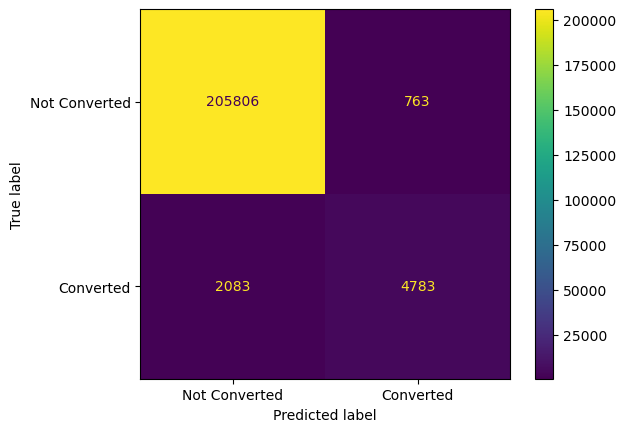

In [20]:
ConfusionMatrixDisplay.from_estimator(classifier, X_train, Y_train, display_labels=['Not Converted', 'Converted'])
plt.show()

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1]
}

classifier_lgb = LGBMClassifier(random_state=0, verbosity=-1)

grid_search = GridSearchCV(
    estimator=classifier_lgb, param_grid=param_grid, cv=3, refit=True, scoring='f1', verbose=1, n_jobs=-1
)
grid_search.fit(X_train, Y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score: ", grid_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/home/raphael/anaconda3/envs/jedha-python/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/raphael/anaconda3/envs/jedha-python/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/raphael/anaconda3/envs/jedha-python/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/raphael/anaconda3/envs/jedha-python/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/raphael/anaconda3/envs/jedha-python/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning

Best parameters found:  {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best F1 score:  0.7628802232374624


In [22]:
classifier = grid_search.best_estimator_
classifier.fit(X_train, Y_train)
Y_train_pred = classifier.predict(X_train)
Y_test_pred = classifier.predict(X_test)
print(Y_train_pred[0:5])
print(Y_test_pred[0:5])

/home/raphael/anaconda3/envs/jedha-python/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/raphael/anaconda3/envs/jedha-python/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[0 0 0 0 0]
[0 0 0 0 0]


In [23]:
proba_train = classifier.predict_proba(X_train)[:, 1]
proba_test = classifier.predict_proba(X_test)[:, 1]

best_seuil = 0.5
best_f1 = 0
for seuil in np.arange(0.1, 0.9, 0.05):
    pred_test = (proba_test >= seuil).astype(int)
    f1 = f1_score(Y_test, pred_test)
    if f1 > best_f1:
        best_f1 = f1
        best_seuil = seuil

print("Seuil optimal :", best_seuil, "| F1 test :", best_f1)

seuil_optimal = best_seuil
Y_train_pred = (proba_train >= seuil_optimal).astype(int)
Y_test_pred = (proba_test >= seuil_optimal).astype(int)

/home/raphael/anaconda3/envs/jedha-python/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/raphael/anaconda3/envs/jedha-python/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



Seuil optimal : 0.40000000000000013 | F1 test : 0.7657822506861848


In [24]:
print("f1-score on train set : ", f1_score(Y_train, Y_train_pred))
print("f1-score on test set : ", f1_score(Y_test, Y_test_pred))
print()
print("recall on train set : ", recall_score(Y_train, Y_train_pred))
print("recall on test set : ", recall_score(Y_test, Y_test_pred)) 
print()
print("precision on train set : ", precision_score(Y_train, Y_train_pred))
print("precision on test set : ", precision_score(Y_test, Y_test_pred))

f1-score on train set :  0.7700420328620557
f1-score on test set :  0.7657822506861848

recall on train set :  0.7337605592775998
recall on test set :  0.7234226447709594

precision on train set :  0.8100980865090851
precision on test set :  0.8134110787172012


In [25]:
# You can also check more performance metrics to better understand what your model is doing
print("Confusion matrix on train set : ")
print(confusion_matrix(Y_train, Y_train_pred))
print()
print("Confusion matrix on test set : ")
print(confusion_matrix(Y_test, Y_test_pred))
print()

Confusion matrix on train set : 
[[205388   1181]
 [  1828   5038]]

Confusion matrix on test set : 
[[68447   384]
 [  640  1674]]



/home/raphael/anaconda3/envs/jedha-python/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



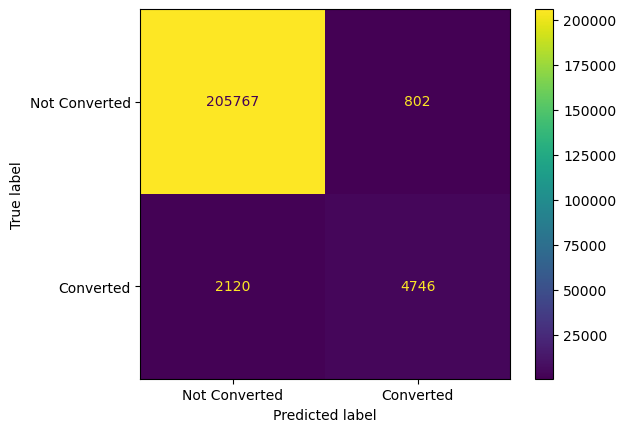

In [26]:
ConfusionMatrixDisplay.from_estimator(classifier, X_train, Y_train, display_labels=['Not Converted', 'Converted'])
plt.show()

**Our baseline model reaches a f1-score of almost 70%. Now, feel free to refine your model and try to beat this score ! 🚀🚀**

# Train best classifier on all data and use it to make predictions on X_without_labels
**Before making predictions on the file conversion_data_test.csv, let's train our model on ALL the data that was in conversion_data_train.csv. Sometimes, this allows to make tiny improvements in the score because we're using more examples to train the model.**

In [27]:
# Concatenate our train and test set to train your best classifier on all data with labels
X = np.append(X_train,X_test,axis=0)
Y = np.append(Y_train,Y_test)

classifier.fit(X,Y)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,3
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [28]:
features_list

Index(['country', 'age', 'new_user', 'source', 'total_pages_visited'], dtype='object')

In [29]:
# Read data without labels
data_without_labels = pd.read_csv('conversion_data_test.csv')
print('Prediction set (without labels) :', data_without_labels.shape)

# Warning : check consistency of features_list (must be the same than the features 
# used by your best classifier)
X_without_labels = data_without_labels.loc[:, features_list]

# Convert pandas DataFrames to arrays before using scikit-learn
# print("Convert pandas DataFrames to arrays...")
# X_without_labels = X_without_labels.values
print("...Done")

print(X_without_labels.head())

Prediction set (without labels) : (31620, 5)
...Done
  country  age  new_user  source  total_pages_visited
0      UK   28         0     Seo                   16
1      UK   22         1  Direct                    5
2   China   32         1     Seo                    1
3      US   32         1     Ads                    6
4   China   25         0     Seo                    3


In [30]:
# WARNING : PUT HERE THE SAME PREPROCESSING AS FOR YOUR TEST SET
# CHECK YOU ARE USING X_without_labels
print("Encoding categorical features and standardizing numerical features...")

X_without_labels = preprocessor.transform(X_without_labels)
print("...Done")
print(X_without_labels[0:5,:])

Encoding categorical features and standardizing numerical features...
...Done
[[-0.31146701 -1.47651318  3.32679652  0.          1.          0.
   0.          1.        ]
 [-1.03787507  0.6772713   0.03773105  0.          1.          0.
   1.          0.        ]
 [ 0.17280504  0.6772713  -1.15829275  0.          0.          0.
   0.          1.        ]
 [ 0.17280504  0.6772713   0.336737    0.          0.          1.
   0.          0.        ]
 [-0.67467104 -1.47651318 -0.56028085  0.          0.          0.
   0.          1.        ]]


In [31]:
# Make predictions and dump to file
# WARNING : MAKE SURE THE FILE IS A CSV WITH ONE COLUMN NAMED 'converted' AND NO INDEX !
# WARNING : FILE NAME MUST HAVE FORMAT 'conversion_data_test_predictions_[name].csv'
# where [name] is the name of your team/model separated by a '-'
# For example : [name] = AURELIE-model1
# data = {
#     'converted': classifier.predict(X_without_labels)
# }
proba_submit = classifier.predict_proba(X_without_labels)[:, 1]
data = {
    'converted': (proba_submit >= seuil_optimal).astype(int)
}

Y_predictions = pd.DataFrame(columns=['converted'],data=data)
Y_predictions.to_csv('conversion_data_test_predictions_Raphael-model2.csv ', index=False)


/home/raphael/anaconda3/envs/jedha-python/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



In [32]:
Y_predictions.value_counts()

converted
0            30711
1              909
Name: count, dtype: int64

## Analyzing the coefficients and interpreting the result
**In this template, we just trained a model with only one feature (total_pages_visited), so there's no analysis to be done about the feature importance 🤔**

**Once you've included more features in your model, please take some time to analyze the model's parameters and try to find some lever for action to improve the newsletter's conversion rate 😎😎**